In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import chi2, norm, fit
from scipy.special import kolmogorov

# Проверка простой гипотезы

Поскольку значения случайной величины могут принимать только значения из $U = \{0, 1, 2, ..., 9\}$, гипотеза $H_0$ однозначно задаёт вероятностную модель.

- $H_0: \xi \sim R(0, 10)$
- $H_1: \overline H_0$

Уровень значимости $\alpha = 0.05$

In [3]:
# data init
DATA = np.array([5, 8, 6, 12, 14, 18, 11, 6, 13, 7], dtype=np.float64)
N = DATA.sum()

## Критерий $\chi^2$ для простой гипотезы

Полная группа событий
$$
\{A_i\}_{i=0}^{9}, ~ A_i = \xi \in [i, i+1) \newline
P_i = {1 \over 10} ~ \forall ~ i \in U
$$

In [4]:
# p_i from probability model
p = np.float64(1.0) / np.float64(10.0)

delta = np.sum(
    (DATA - N * p) ** 2 /
    (N * p)
)

# p-value calculation
chi2.sf(delta,  df=(DATA.size - 1))  # 1 - F(x)

np.float64(0.058984030544419454)

**Вывод**: Нет весомых оснований отвергнуть основную гипотезу.

## Критерий Колмогорова для простой гипотезы

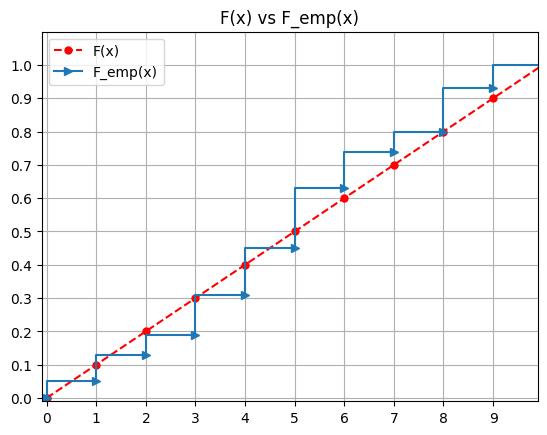

In [5]:
F_emp = np.cumsum(DATA / N)
F_hyp = np.cumsum(np.ones(11) / 10) - np.ones_like(11) / 10

plt.plot(
    np.concatenate((F_hyp, [1])),
    marker='.',
    ms=10,
    label='F(x)',
    ls='--',
    c='r'
)
plt.plot(
    np.concatenate(([0], F_emp)),
    drawstyle='steps',
    marker='>',
    label='F_emp(x)',
    ls='-'
)

plt.ylim(-0.01, 1.1)
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlim(-0.1, 9.9)
plt.xticks(np.arange(0, 10, 1))

plt.legend()
plt.title("F(x) vs F_emp(x)")

plt.grid(True)

plt.show()

In [6]:
delta = np.sqrt(N) * max(
    np.max(np.concatenate(([0], F_emp)) - F_hyp),  # lower
    np.max(np.concatenate((F_emp, [1])) - F_hyp)  # upper
)

# p-value
kolmogorov(delta)

np.float64(0.039681879538114355)

**Вывод**: Отвергаем гипотезу.

# Пункт b: проверка сложной гипотезы

- $H_0: \xi \sim N(\theta_1, \theta_2^2), ~ \theta_1 \in R, ~ \theta_2 > 0$
- $H_1: \overline H_0$

Уровень значимости $\alpha = 0.05$

In [13]:
SAMPLE = np.array(
    [0] * 5 +
    [1] * 8 +
    [2] * 6 +
    [3] * 12 +
    [4] * 14 +
    [5] * 18 +
    [6] * 11 +
    [7] * 6 +
    [8] * 13 +
    [9] * 7,
    dtype=np.float64
)

est = fit(norm, SAMPLE, bounds=((-50, 50), (0, 10)), method='mle').params # group maximum likehood est

## Критерий $\chi^2$ для сложной гипотезы

Полная группа событий
$$
\{A_i\}_{i=0}^{9}, ~ A_i = \xi \in [i, i+1) \newline
P_i = F(i + 1) - F(i) ~ \forall ~ i \in U
$$

In [ ]:
P_i = norm.cdf(np.arange(1, 11, 1), loc=est.loc, scale=est.scale) - norm.cdf(np.arange(0, 10, 1), loc=est.loc, scale=est.scale)

delta = np.sum(
    (DATA - N * P_i) ** 2 /
    (N * P_i)
)

chi2.sf(delta, df=(10 - 2 - 1))  # 1 - F(x)

np.float64(0.010919677974077871)

**Вывод**: отвергаем гипотезу.

## Критерий Колмогорова для сложной гипотезы

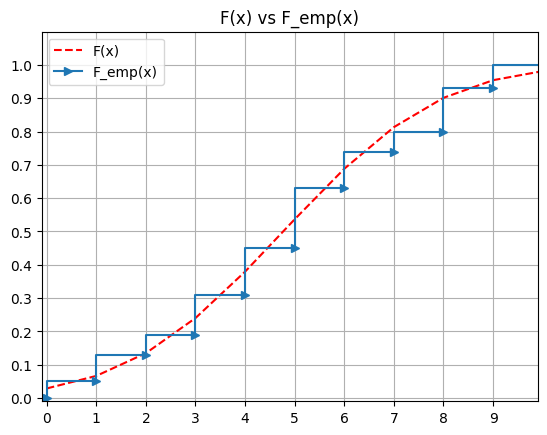

In [11]:
F_emp = np.cumsum(DATA / N)
F_hyp = norm.cdf(np.arange(0, 11, 1), loc=est.loc, scale=est.scale)

plt.plot(
    np.arange(0, 11, 1),
    F_hyp,
    label='F(x)',
    ls='--',
    c='r'
)
plt.plot(
    np.concatenate(([0], F_emp)),
    drawstyle='steps',
    marker='>',
    label='F_emp(x)',
    ls='-'
)

plt.ylim(-0.01, 1.1)
plt.yticks(np.arange(0, 1.1, 0.1))

plt.xlim(-0.1, 9.9)
plt.xticks(np.arange(0, 10, 1))

plt.legend()
plt.title("F(x) vs F_emp(x)")

plt.grid(True)

plt.show()

In [12]:
delta = np.sqrt(N) * max(
    np.max(np.concatenate(([0], F_emp)) - F_hyp),  # lower
    np.max(np.concatenate((F_emp, [1])) - F_hyp)  # upper
)

# p-value
kolmogorov(delta)

np.float64(0.3471732448189535)